# Phase II MLP Workflow for Diabetes Prediction

This notebook walks through the MLP part of the project in the same order we used in the report. The goal is simple: use the BRFSS health indicators to predict `Diabetes_binary`, compare the neural network to basic baselines, and see whether tuning the MLP improves the result.


In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_WITHIN_TRAIN = 0.20
THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30]

DATA_PATH = Path("/Users/zansong/Desktop/203C/Project/archive-6/diabetes_binary_health_indicators_BRFSS2015.csv")
BLUE = "#8FBCD4"
RED = "#E26D5A"
GREEN = "#5B8E7D"
PURPLE = "#B07AA1"


## 1. Load the data and create the train / validation / test split

I kept the split aligned with the rest of the project. The data are first split into train and test sets, and then the training data are split again to create a validation set. The point of doing this is to keep the test set untouched until the very end.


In [ ]:
df = pd.read_csv(DATA_PATH)
y = df["Diabetes_binary"].astype(int)
X = df.drop(columns=["Diabetes_binary"])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SIZE_WITHIN_TRAIN,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

split_df = pd.DataFrame(
    [
        {"subset": "Train", "n_rows": len(X_train), "positive_rate": y_train.mean()},
        {"subset": "Validation", "n_rows": len(X_val), "positive_rate": y_val.mean()},
        {"subset": "Test", "n_rows": len(X_test), "positive_rate": y_test.mean()},
    ]
)

print(f"Dataset shape: {df.shape}")
print(f"Number of predictors: {X.shape[1]}")
split_df


## 2. Standardize the predictors

The MLP is sensitive to the scale of the input variables, so the predictors are standardized before training. The scaler is fit on the training subset only, then applied to the validation and test sets without refitting.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


## 3. Define helper functions and model routines

This section sets up the functions used later in the notebook. That includes metric calculation, threshold selection, the baseline models, the initial MLP, and the candidate MLP configurations used for tuning.


In [ ]:
@dataclass
class ModelArtifacts:
    name: str
    estimator: object | None
    threshold: float | None
    val_prauc: float | None
    val_roc_auc: float | None
    val_recall: float | None
    val_precision: float | None
    val_f1: float | None
    test_metrics: dict[str, float]
    test_probs: np.ndarray
    test_preds: np.ndarray


def compute_metrics(y_true: pd.Series | np.ndarray, y_prob: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Brier Score": brier_score_loss(y_true, y_prob),
    }


def pick_threshold(y_true: pd.Series, y_prob: np.ndarray, thresholds: Iterable[float], recall_floor: float | None = None) -> dict[str, float]:
    candidates = []
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        candidates.append(
            {
                "threshold": thr,
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )

    if recall_floor is not None:
        filtered = [row for row in candidates if row["recall"] >= recall_floor]
        if filtered:
            candidates = filtered

    return sorted(
        candidates,
        key=lambda row: (row["f1"], row["recall"], row["precision"], -row["threshold"]),
        reverse=True,
    )[0]


def build_majority_baseline(y_test: pd.Series) -> ModelArtifacts:
    y_prob = np.zeros(len(y_test), dtype=float)
    y_pred = np.zeros(len(y_test), dtype=int)
    metrics = compute_metrics(y_test, y_prob, y_pred)
    return ModelArtifacts(
        name="Majority Class",
        estimator=None,
        threshold=None,
        val_prauc=None,
        val_roc_auc=None,
        val_recall=None,
        val_precision=None,
        val_f1=None,
        test_metrics=metrics,
        test_probs=y_prob,
        test_preds=y_pred,
    )


def fit_logistic_baseline(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, recall_floor):
    model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)

    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    chosen = pick_threshold(y_val, y_val_prob, THRESHOLDS, recall_floor=recall_floor)

    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = (y_test_prob >= chosen["threshold"]).astype(int)
    metrics = compute_metrics(y_test, y_test_prob, y_test_pred)

    return ModelArtifacts(
        name="Logistic Regression",
        estimator=model,
        threshold=chosen["threshold"],
        val_prauc=average_precision_score(y_val, y_val_prob),
        val_roc_auc=roc_auc_score(y_val, y_val_prob),
        val_recall=chosen["recall"],
        val_precision=chosen["precision"],
        val_f1=chosen["f1"],
        test_metrics=metrics,
        test_probs=y_test_prob,
        test_preds=y_test_pred,
    )


def fit_initial_mlp(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test):
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)

    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    chosen = pick_threshold(y_val, y_val_prob, THRESHOLDS)

    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = (y_test_prob >= chosen["threshold"]).astype(int)
    metrics = compute_metrics(y_test, y_test_prob, y_test_pred)

    return ModelArtifacts(
        name="Initial MLP",
        estimator=model,
        threshold=chosen["threshold"],
        val_prauc=average_precision_score(y_val, y_val_prob),
        val_roc_auc=roc_auc_score(y_val, y_val_prob),
        val_recall=chosen["recall"],
        val_precision=chosen["precision"],
        val_f1=chosen["f1"],
        test_metrics=metrics,
        test_probs=y_test_prob,
        test_preds=y_test_pred,
    )


def candidate_grid():
    return [
        {"hidden_layer_sizes": (32,), "alpha": 0.0001, "learning_rate_init": 0.001, "batch_size": 64},
        {"hidden_layer_sizes": (64,), "alpha": 0.0001, "learning_rate_init": 0.001, "batch_size": 64},
        {"hidden_layer_sizes": (128, 64), "alpha": 0.0001, "learning_rate_init": 0.001, "batch_size": 64},
        {"hidden_layer_sizes": (64, 32), "alpha": 0.001, "learning_rate_init": 0.001, "batch_size": 64},
        {"hidden_layer_sizes": (64, 32), "alpha": 0.0001, "learning_rate_init": 0.0005, "batch_size": 64},
        {"hidden_layer_sizes": (64, 32), "alpha": 0.0001, "learning_rate_init": 0.001, "batch_size": 32},
        {"hidden_layer_sizes": (128, 64), "alpha": 0.001, "learning_rate_init": 0.0005, "batch_size": 32},
        {"hidden_layer_sizes": (64,), "alpha": 0.001, "learning_rate_init": 0.0005, "batch_size": 32},
        {"hidden_layer_sizes": (128, 64), "alpha": 0.0001, "learning_rate_init": 0.0005, "batch_size": 64},
    ]


def fit_candidate(config, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, recall_floor):
    model = MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=100,
        early_stopping=True,
        random_state=RANDOM_STATE,
        **config,
    )
    model.fit(X_train_scaled, y_train)

    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    chosen = pick_threshold(y_val, y_val_prob, THRESHOLDS, recall_floor=recall_floor)

    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = (y_test_prob >= chosen["threshold"]).astype(int)
    metrics = compute_metrics(y_test, y_test_prob, y_test_pred)

    artifacts = ModelArtifacts(
        name="Optimized MLP",
        estimator=model,
        threshold=chosen["threshold"],
        val_prauc=average_precision_score(y_val, y_val_prob),
        val_roc_auc=roc_auc_score(y_val, y_val_prob),
        val_recall=chosen["recall"],
        val_precision=chosen["precision"],
        val_f1=chosen["f1"],
        test_metrics=metrics,
        test_probs=y_test_prob,
        test_preds=y_test_pred,
    )

    row = {
        "hidden_layer_sizes": str(config["hidden_layer_sizes"]),
        "alpha": config["alpha"],
        "learning_rate_init": config["learning_rate_init"],
        "batch_size": config["batch_size"],
        "val_PR_AUC": artifacts.val_prauc,
        "val_ROC_AUC": artifacts.val_roc_auc,
        "selected_threshold": artifacts.threshold,
        "val_recall_at_threshold": artifacts.val_recall,
        "val_precision_at_threshold": artifacts.val_precision,
        "val_f1_at_threshold": artifacts.val_f1,
        "test_PR_AUC": artifacts.test_metrics["PR AUC"],
        "test_recall": artifacts.test_metrics["Recall"],
        "test_precision": artifacts.test_metrics["Precision"],
        "test_f1": artifacts.test_metrics["F1-score"],
    }
    return artifacts, row


## 4. Fit the baselines and the initial MLP

This step fits the majority-class baseline, the logistic-regression baseline, and the initial MLP. The logistic threshold is chosen with reference to the initial MLP validation recall so that the comparison stays tied to the same recall-first logic used in the project.


In [ ]:
majority = build_majority_baseline(y_test)
initial = fit_initial_mlp(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test)
logistic = fit_logistic_baseline(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test,
    recall_floor=initial.val_recall or 0.0,
)

print("Initial MLP validation PR-AUC:", round(initial.val_prauc, 3))
print("Initial MLP selected threshold:", initial.threshold)
print("Logistic selected threshold:", logistic.threshold)


## 5. Hyperparameter search

Instead of trying a huge number of models, this notebook checks a small set of reasonable MLP configurations. The main selection metric is validation `PR-AUC`. If two candidates are close, validation recall and then validation F1 are used to break the tie.


In [ ]:
candidate_results = []
best_candidate_artifacts = None
best_candidate_row = None

for idx, config in enumerate(candidate_grid(), start=1):
    artifacts, row = fit_candidate(
        config,
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val,
        X_test_scaled,
        y_test,
        recall_floor=initial.val_recall or 0.0,
    )
    print(
        f"candidate {idx}: layers={config['hidden_layer_sizes']} alpha={config['alpha']} "
        f"lr={config['learning_rate_init']} batch={config['batch_size']} "
        f"val_pr_auc={row['val_PR_AUC']:.3f} val_recall={row['val_recall_at_threshold']:.3f}"
    )
    candidate_results.append(row)

    if best_candidate_artifacts is None:
        best_candidate_artifacts = artifacts
        best_candidate_row = row
        continue

    current_key = (row['val_PR_AUC'], row['val_recall_at_threshold'], row['val_f1_at_threshold'])
    best_key = (
        best_candidate_row['val_PR_AUC'],
        best_candidate_row['val_recall_at_threshold'],
        best_candidate_row['val_f1_at_threshold'],
    )
    if current_key > best_key:
        best_candidate_artifacts = artifacts
        best_candidate_row = row

optimized = best_candidate_artifacts
tuning_df = pd.DataFrame(candidate_results).sort_values(
    by=['val_PR_AUC', 'val_recall_at_threshold', 'val_f1_at_threshold'],
    ascending=False,
).reset_index(drop=True)

tuning_df.head(5)


## 6. Compare test-set performance

This table puts the four models side by side on the held-out test set: the majority baseline, logistic regression, the initial MLP, and the optimized MLP.


In [ ]:
metrics_rows = []
for artifact in [majority, logistic, initial, optimized]:
    metrics_rows.append(
        {
            "Model": artifact.name,
            "Threshold": artifact.threshold if artifact.threshold is not None else np.nan,
            **artifact.test_metrics,
        }
    )

metrics_df = pd.DataFrame(metrics_rows)
metrics_df


## 7. Precision-recall curves

This figure shows how the logistic baseline, the initial MLP, and the optimized MLP compare on precision-recall behavior for the positive class.


In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 7.5))
palette = {
    "Logistic Regression": BLUE,
    "Initial MLP": RED,
    "Optimized MLP": GREEN,
}

for item in [logistic, initial, optimized]:
    precision, recall, _ = precision_recall_curve(y_test, item.test_probs)
    ax.plot(
        recall,
        precision,
        linewidth=3,
        color=palette[item.name],
        label=f"{item.name} (PR-AUC={item.test_metrics['PR AUC']:.3f})",
    )

ax.axhline(y=float(np.mean(y_test)), color=PURPLE, linestyle="--", linewidth=2, label=f"Prevalence baseline ({np.mean(y_test):.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves on the Held-Out Test Set")
ax.legend(frameon=True, loc="best")
plt.show()


### Figure preview

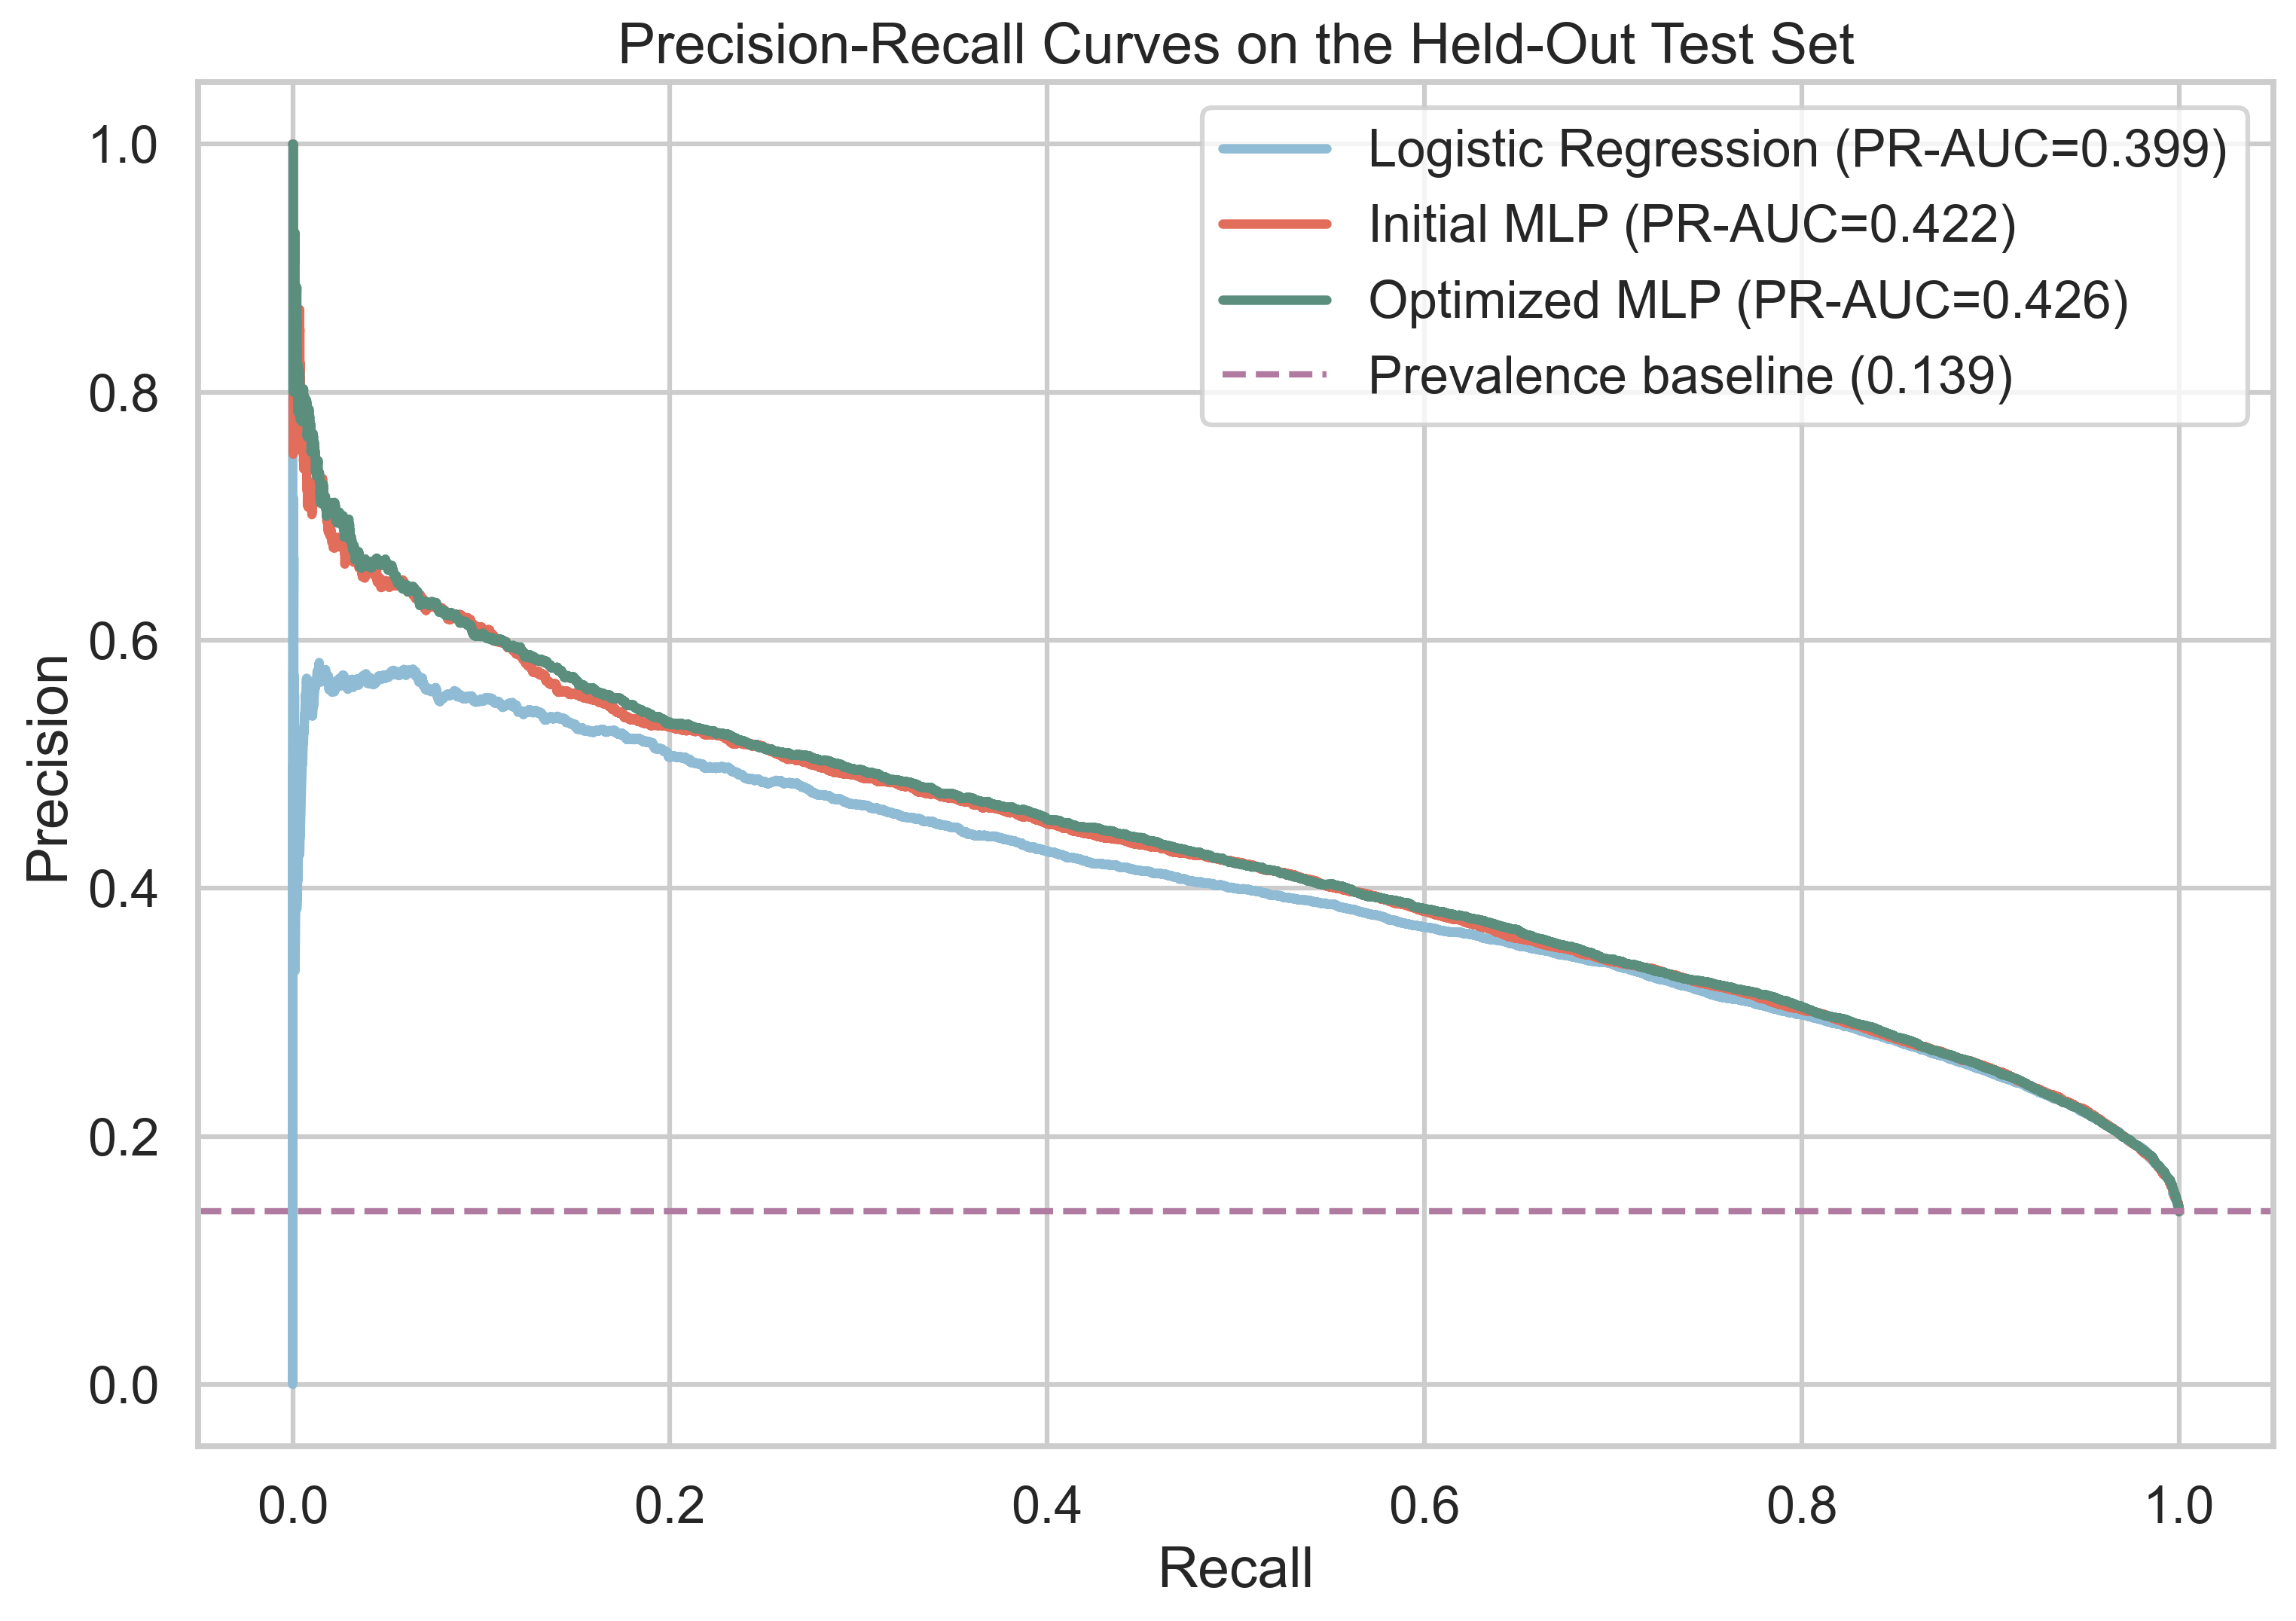

## 8. Threshold trade-off for the optimized MLP

This figure shows what happens to recall and precision when the classification threshold changes for the optimized MLP on the validation set.


In [ ]:
rows = []
val_probs_optimized = optimized.estimator.predict_proba(X_val_scaled)[:, 1]
for thr in THRESHOLDS:
    y_pred = (val_probs_optimized >= thr).astype(int)
    rows.append(
        {
            "threshold": thr,
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "precision": precision_score(y_val, y_pred, zero_division=0),
        }
    )
tradeoff_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10.5, 7.5))
ax.plot(tradeoff_df["threshold"], tradeoff_df["recall"], marker="o", linewidth=3, color=RED, label="Recall")
ax.plot(tradeoff_df["threshold"], tradeoff_df["precision"], marker="o", linewidth=3, color=BLUE, label="Precision")
ax.axvline(optimized.threshold, color=GREEN, linestyle="--", linewidth=2, label=f"Selected threshold = {optimized.threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.02)
ax.set_title("Validation Threshold Trade-off for Optimized MLP")
ax.legend(frameon=True, loc="best")
plt.show()

tradeoff_df


### Figure preview

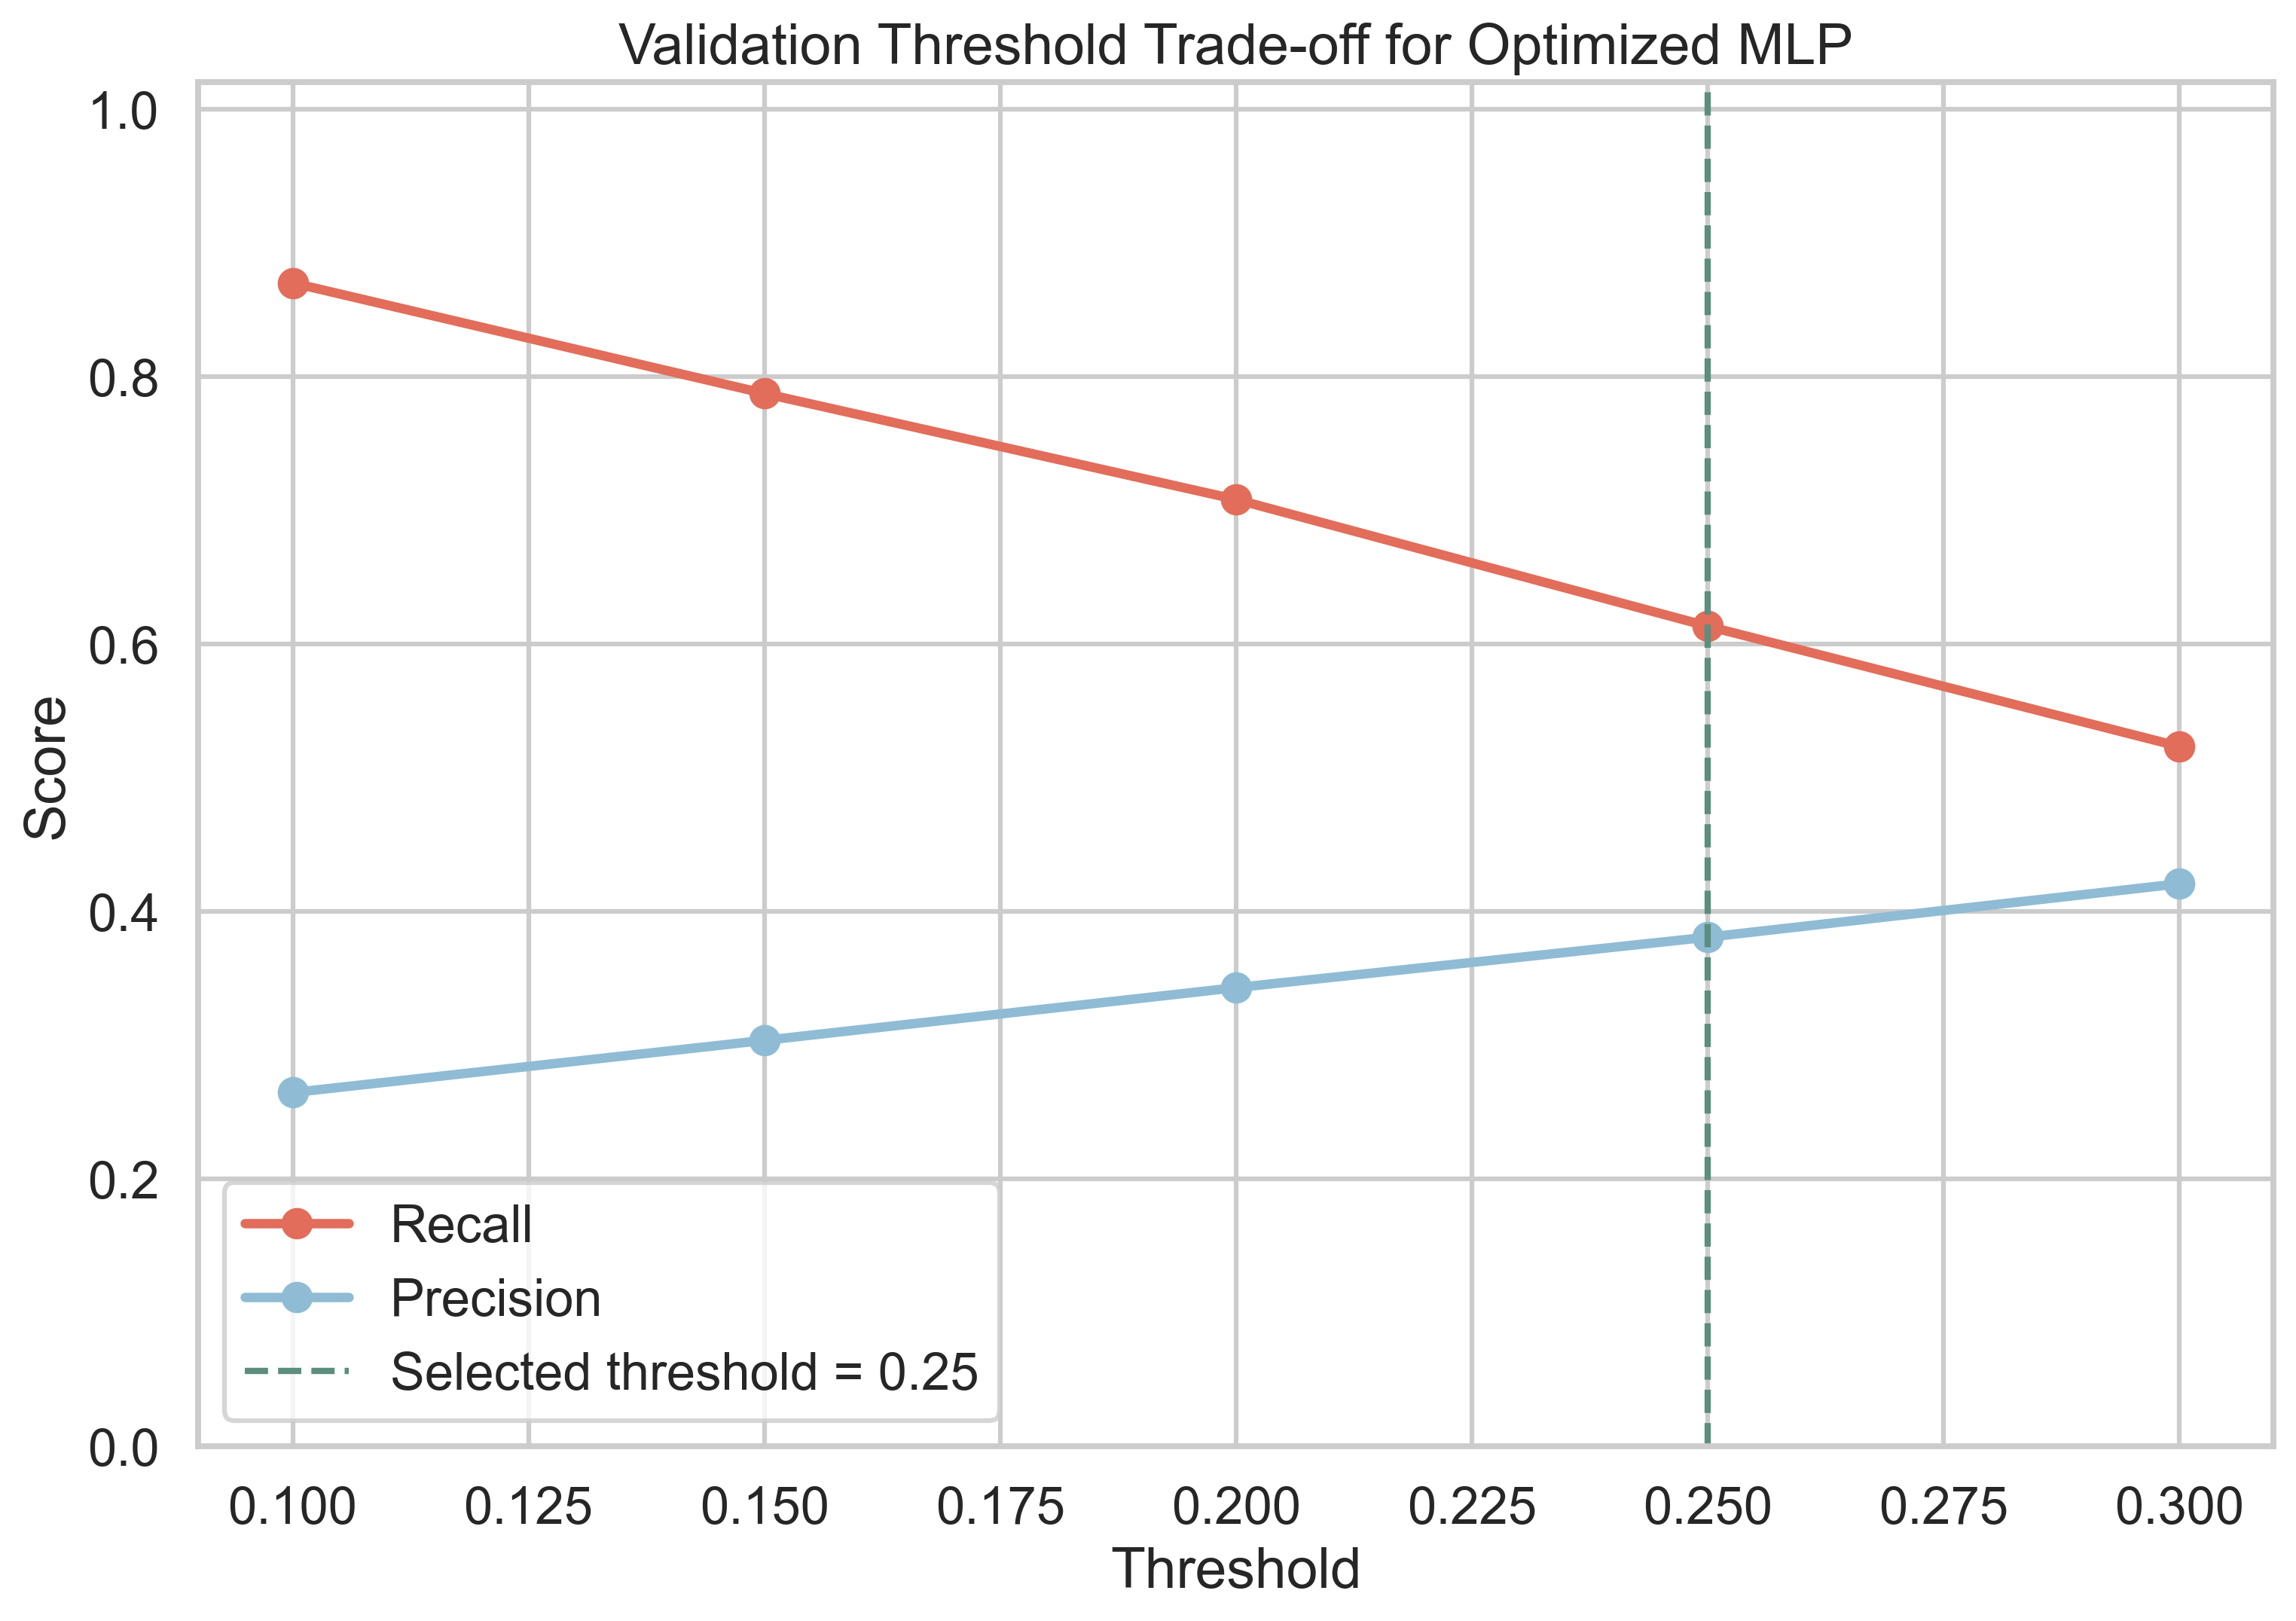

## 9. Confusion matrix and error analysis

This section looks at the final mistakes made by the optimized MLP on the held-out test set.


In [ ]:
cm = confusion_matrix(y_test, optimized.test_preds)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp)

fig, ax = plt.subplots(figsize=(8.0, 6.8))
sns.heatmap(cm, annot=True, fmt="d", cmap=sns.light_palette(RED, as_cmap=True), cbar=False, ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticklabels(["No diabetes", "Diabetes"], rotation=0)
ax.set_yticklabels(["No diabetes", "Diabetes"], rotation=0)
ax.set_title("Optimized MLP Confusion Matrix on the Test Set")
plt.show()

error_summary = pd.DataFrame(
    [{
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FNR": fnr,
    }]
)
error_summary


### Figure preview

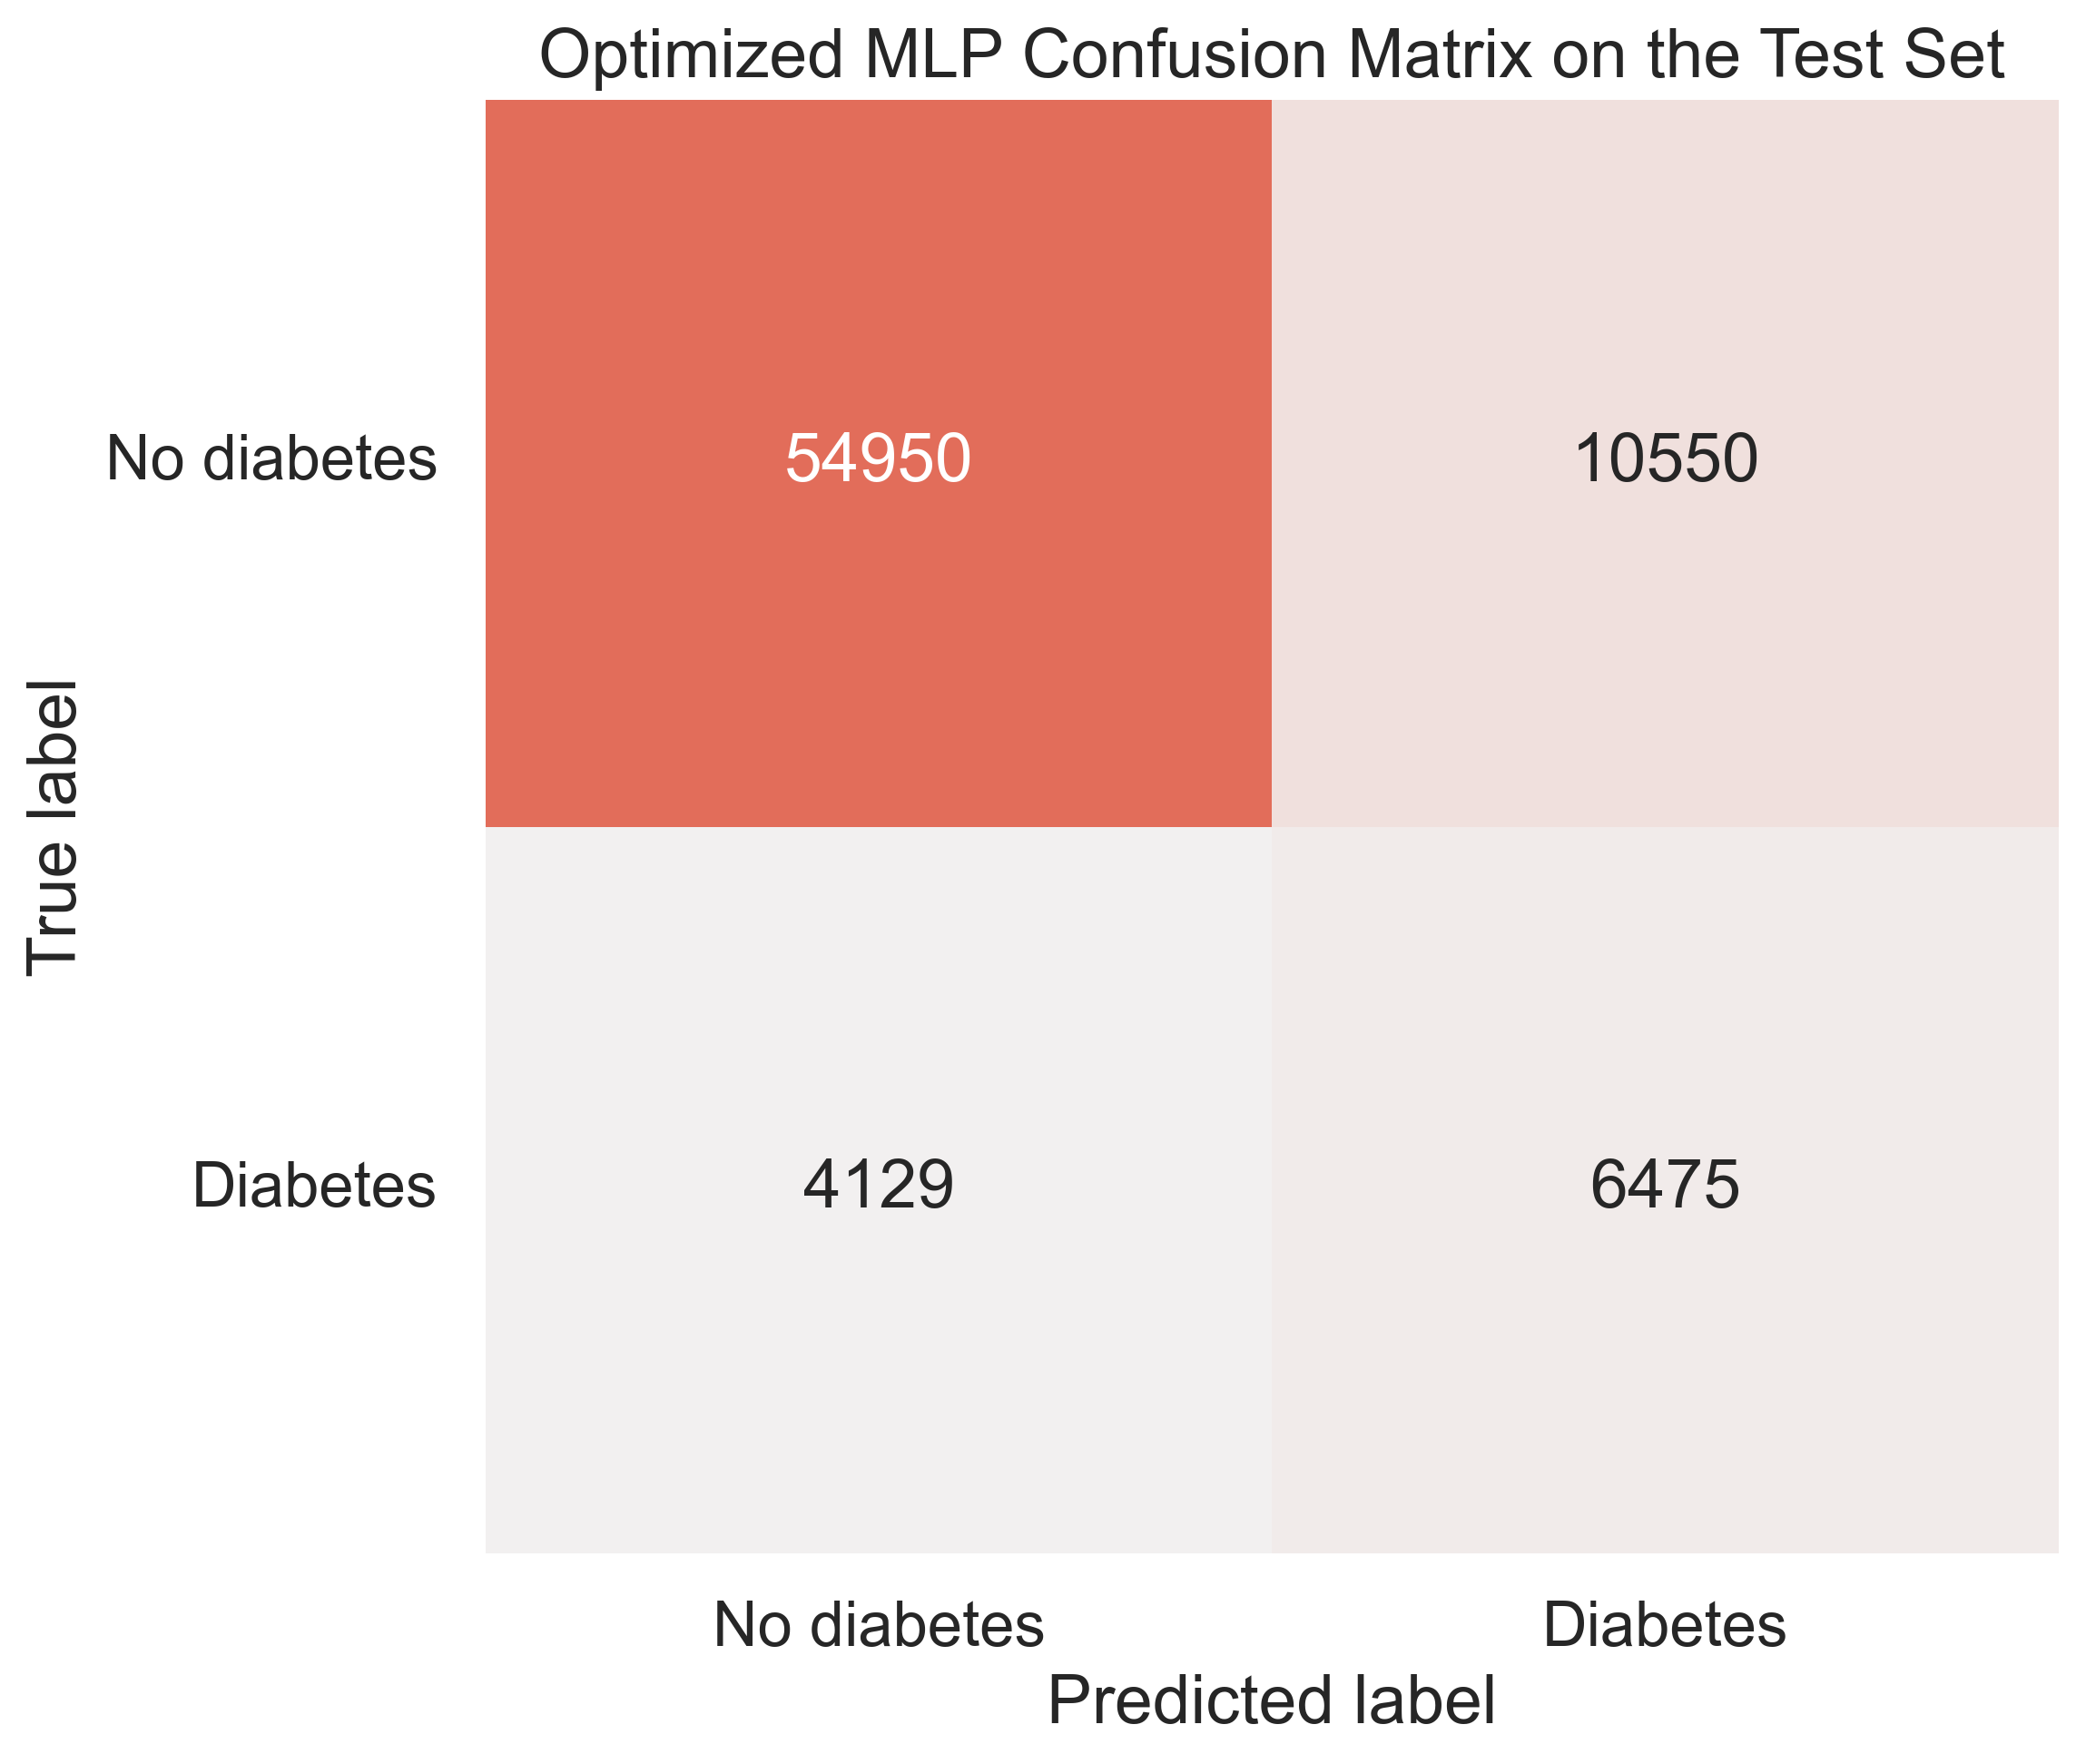